In [445]:
import zipfile
import os
import pandas as pd

zip_file_path = '/content/house-prices-advanced-regression-techniques.zip'
extraction_path = '/content/house_prices_data'

# Create the extraction directory if it doesn't exist
os.makedirs(extraction_path, exist_ok=True)

# Unzip the file
with zipfile.ZipFile(zip_file_path, 'r') as zip_ref:
    zip_ref.extractall(extraction_path)

print(f"Files extracted to: {extraction_path}")
print("Contents of the extracted directory:")
for dirname, _, filenames in os.walk(extraction_path):
    for filename in filenames:
        print(os.path.join(dirname, filename))

Files extracted to: /content/house_prices_data
Contents of the extracted directory:
/content/house_prices_data/sample_submission.csv
/content/house_prices_data/data_description.txt
/content/house_prices_data/train.csv
/content/house_prices_data/test.csv


In [446]:
# Define paths to the train and test CSV files
train_csv_path = os.path.join(extraction_path, 'train.csv')
test_csv_path = os.path.join(extraction_path, 'test.csv')

# Load the datasets into pandas DataFrames
train_df = pd.read_csv(train_csv_path)
test_df = pd.read_csv(test_csv_path)


In [447]:
train_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1460 entries, 0 to 1459
Data columns (total 81 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Id             1460 non-null   int64  
 1   MSSubClass     1460 non-null   int64  
 2   MSZoning       1460 non-null   object 
 3   LotFrontage    1201 non-null   float64
 4   LotArea        1460 non-null   int64  
 5   Street         1460 non-null   object 
 6   Alley          91 non-null     object 
 7   LotShape       1460 non-null   object 
 8   LandContour    1460 non-null   object 
 9   Utilities      1460 non-null   object 
 10  LotConfig      1460 non-null   object 
 11  LandSlope      1460 non-null   object 
 12  Neighborhood   1460 non-null   object 
 13  Condition1     1460 non-null   object 
 14  Condition2     1460 non-null   object 
 15  BldgType       1460 non-null   object 
 16  HouseStyle     1460 non-null   object 
 17  OverallQual    1460 non-null   int64  
 18  OverallC

In [448]:
pd.set_option('display.max_columns', None)
display(train_df.head(10))

,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,LotConfig,LandSlope,Neighborhood,Condition1,Condition2,BldgType,HouseStyle,OverallQual,OverallCond,YearBuilt,YearRemodAdd,RoofStyle,RoofMatl,Exterior1st,Exterior2nd,MasVnrType,MasVnrArea,ExterQual,ExterCond,Foundation,BsmtQual,BsmtCond,BsmtExposure,BsmtFinType1,BsmtFinSF1,BsmtFinType2,BsmtFinSF2,BsmtUnfSF,TotalBsmtSF,Heating,HeatingQC,CentralAir,Electrical,1stFlrSF,2ndFlrSF,LowQualFinSF,GrLivArea,BsmtFullBath,BsmtHalfBath,FullBath,HalfBath,BedroomAbvGr,KitchenAbvGr,KitchenQual,TotRmsAbvGrd,Functional,Fireplaces,FireplaceQu,GarageType,GarageYrBlt,GarageFinish,GarageCars,GarageArea,GarageQual,GarageCond,PavedDrive,WoodDeckSF,OpenPorchSF,EnclosedPorch,3SsnPorch,ScreenPorch,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
0,1,60,RL,65.0,8450,Pave,NaN,Reg,Lvl,AllPub,Inside,Gtl,CollgCr,Norm,Norm,1Fam,2Story,7,5,2003,2003,Gable,CompShg,VinylSd,VinylSd,BrkFace,196.0,Gd,TA,PConc,Gd,TA,No,GLQ,706,Unf,0,150,856,GasA,Ex,Y,SBrkr,856,854,0,1710,1,0,2,1,3,1,Gd,8,Typ,0,NaN,Attchd,2003.0,RFn,2,548,TA,TA,Y,0,61,0,0,0,0,NaN,NaN,NaN,0,2,2008,WD,Normal,208500
1,2,20,RL,80.0,9600,Pave,NaN,Reg,Lvl,AllPub,FR2,Gtl,Veenker,Feedr,Norm,1Fam,1Story,6,8,1976,1976,Gable,CompShg,MetalSd,MetalSd,NaN,0.0,TA,TA,CBlock,Gd,TA,Gd,ALQ,978,Unf,0,284,1262,GasA,Ex,Y,SBrkr,1262,0,0,1262,0,1,2,0,3,1,TA,6,Typ,1,TA,Attchd,1976.0,RFn,2,460,TA,TA,Y,298,0,0,0,0,0,NaN,NaN,NaN,0,5,2007,WD,Normal,181500
2,3,60,RL,68.0,11250,Pave,NaN,IR1,Lvl,AllPub,Inside,Gtl,CollgCr,Norm,Norm,1Fam,2Story,7,5,2001,2002,Gable,CompShg,VinylSd,VinylSd,BrkFace,162.0,Gd,TA,PConc,Gd,TA,Mn,GLQ,486,Unf,0,434,920,GasA,Ex,Y,SBrkr,920,866,0,1786,1,0,2,1,3,1,Gd,6,Typ,1,TA,Attchd,2001.0,RFn,2,608,TA,TA,Y,0,42,0,0,0,0,NaN,NaN,NaN,0,9,2008,WD,Normal,223500
3,4,70,RL,60.0,9550,Pave,NaN,IR1,Lvl,AllPub,Corner,Gtl,Crawfor,Norm,Norm,1Fam,2Story,7,5,1915,1970,Gable,CompShg,Wd Sdng,Wd Shng,NaN,0.0,TA,TA,BrkTil,TA,Gd,No,ALQ,216,Unf,0,540,756,GasA,Gd,Y,SBrkr,961,756,0,1717,1,0,1,0,3,1,Gd,7,Typ,1,Gd,Detchd,1998.0,Unf,3,642,TA,TA,Y,0,35,272,0,0,0,NaN,NaN,NaN,0,2,2006,WD,Abnorml,140000
4,5,60,RL,84.0,14260,Pave,NaN,IR1,Lvl,AllPub,FR2,Gtl,NoRidge,Norm,Norm,1Fam,2Story,8,5,2000,2000,Gable,CompShg,VinylSd,VinylSd,BrkFace,350.0,Gd,TA,PConc,Gd,TA,Av,GLQ,655,Unf,0,490,1145,GasA,Ex,Y,SBrkr,1145,1053,0,2198,1,0,2,1,4,1,Gd,9,Typ,1,TA,Attchd,2000.0,RFn,3,836,TA,TA,Y,192,84,0,0,0,0,NaN,NaN,NaN,0,12,2008,WD,Normal,250000
5,6,50,RL,85.0,14115,Pave,NaN,IR1,Lvl,AllPub,Inside,Gtl,Mitchel,Norm,Norm,1Fam,1.5Fin,5,5,1993,1995,Gable,CompShg,VinylSd,VinylSd,NaN,0.0,TA,TA,Wood,Gd,TA,No,GLQ,732,Unf,0,64,796,GasA,Ex,Y,SBrkr,796,566,0,1362,1,0,1,1,1,1,TA,5,Typ,0,NaN,Attchd,1993.0,Unf,2,480,TA,TA,Y,40,30,0,320,0,0,NaN,MnPrv,Shed,700,10,2009,WD,Normal,143000
6,7,20,RL,75.0,10084,Pave,NaN,Reg,Lvl,AllPub,Inside,Gtl,Somerst,Norm,Norm,1Fam,1Story,8,5,2004,2005,Gable,CompShg,VinylSd,VinylSd,Stone,186.0,Gd,TA,PConc,Ex,TA,Av,GLQ,1369,Unf,0,317,1686,GasA,Ex,Y,SBrkr,1694,0,0,1694,1,0,2,0,3,1,Gd,7,Typ,1,Gd,Attchd,2004.0,RFn,2,636,TA,TA,Y,255,57,0,0,0,0,NaN,NaN,NaN,0,8,2007,WD,Normal,307000
7,8,60,RL,NaN,10382,Pave,NaN,IR1,Lvl,AllPub,Corner,Gtl,NWAmes,PosN,Norm,1Fam,2Story,7,6,1973,1973,Gable,CompShg,HdBoard,HdBoard,Stone,240.0,TA,TA,CBlock,Gd,TA,Mn,ALQ,859,BLQ,32,216,1107,GasA,Ex,Y,SBrkr,1107,983,0,2090,1,0,2,1,3,1,TA,7,Typ,2,TA,Attchd,1973.0,RFn,2,484,TA,TA,Y,235,204,228,0,0,0,NaN,NaN,Shed,350,11,2009,WD,Normal,200000
8,9,50,RM,51.0,6120,Pave,NaN,Reg,Lvl,AllPub,Inside,Gtl,OldTown,Artery,Norm,1Fam,1.5Fin,7,5,1931,1950,Gable,CompShg,BrkFace,Wd Shng,NaN,0.0,TA,TA,BrkTil,TA,TA,No,Unf,0,Unf,0,952,952,GasA,Gd,Y,FuseF,1022,752,0,1774,0,0,2,0,2,2,TA,8,Min1,2,TA,Detchd,1931.0,Unf,2,468,Fa,TA,Y,90,0,205,0,0,0,NaN,NaN,NaN,0,4,2008,WD,Abnorml,129900
9,10,190,RL,50.0,7420,Pave,NaN,Reg,Lvl,AllPub,Corner,Gtl,BrkSide,Artery,Artery,2fmCon,1.5Unf,5,6,1939,1950,Gable,CompShg,MetalSd,MetalSd,NaN,0.0,TA,TA,BrkTil,TA,TA,No,GLQ,851,Unf,0,140,991,GasA,Ex,

In [449]:
train_df.shape

(1460, 81)

In [450]:
train_df.describe()

,Id,MSSubClass,LotFrontage,LotArea,OverallQual,OverallCond,YearBuilt,YearRemodAdd,MasVnrArea,BsmtFinSF1,BsmtFinSF2,BsmtUnfSF,TotalBsmtSF,1stFlrSF,2ndFlrSF,LowQualFinSF,GrLivArea,BsmtFullBath,BsmtHalfBath,FullBath,HalfBath,BedroomAbvGr,KitchenAbvGr,TotRmsAbvGrd,Fireplaces,GarageYrBlt,GarageCars,GarageArea,WoodDeckSF,OpenPorchSF,EnclosedPorch,3SsnPorch,ScreenPorch,PoolArea,MiscVal,MoSold,YrSold,SalePrice
count,1460.000000,1460.000000,1201.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1452.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1379.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000
mean,730.500000,56.897260,70.049958,10516.828082,6.099315,5.575342,1971.267808,1984.865753,103.685262,443.639726,46.549315,567.240411,1057.429452,1162.626712,346.992466,5.844521,1515.463699,0.425342,0.057534,1.565068,0.382877,2.866438,1.046575,6.517808,0.613014,1978.506164,1.767123,472.980137,94.244521,46.660274,21.954110,3.409589,15.060959,2.758904,43.489041,6.321918,2007.815753,180921.195890
std,421.610009,42.300571,24.284752,9981.264932,1.382997,1.112799,30.202904,20.645407,181.066207,456.098091,161.319273,441.866955,438.705324,386.587738,436.528436,48.623081,525.480383,0.518911,0.238753,0.550916,0.502885,0.815778,0.220338,1.625393,0.644666,24.689725,0.747315,213.804841,125.338794,66.256028,61.119149,29.317331,55.757415,40.177307,496.123024,2.703626,1.328095,79442.502883
min,1.000000,20.000000,21.000000,1300.000000,1.000000,1.000000,1872.000000,1950.000000,0.000000,0.000000,0.000000,0.000000,0.000000,334.000000,0.000000,0.000000,334.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,2.000000,0.000000,1900.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,2006.000000,34900.000000
25%,365.750000,20.000000,59.000000,7553.500000,5.000000,5.000000,1954.000000,1967.000000,0.000000,0.000000,0.000000,223.000000,795.750000,882.000000,0.000000,0.000000,1129.500000,0.000000,0.000000,1.000000,0.000000,2.000000,1.000000,5.000000,0.000000,1961.000000,1.000000,334.500000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,5.000000,2007.000000,129975.000000
50%,730.500000,50.000000,69.000000,9478.500000,6.000000,5.000000,1973.000000,1994.000000,0.000000,383.500000,0.000000,477.500000,991.500000,1087.000000,0.000000,0.000000,1464.000000,0.000000,0.000000,2.000000,0.000000,3.000000,1.000000,6.000000,1.000000,1980.000000,2.000000,480.000000,0.000000,25.000000,0.000000,0.000000,0.000000,0.000000,0.000000,6.000000,2008.000000,163000.000000
75%,1095.250000,70.000000,80.000000,11601.500000,7.000000,6.000000,2000.000000,2004.000000,166.000000,712.250000,0.000000,808.000000,1298.250000,1391.250000,728.000000,0.000000,1776.750000,1.000000,0.000000,2.000000,1.000000,3.000000,1.000000,7.000000,1.000000,2002.000000,2.000000,576.000000,168.000000,68.000000,0.000000,0.000000,0.000000,0.000000,0.000000,8.000000,2009.000000,214000.000000
max,1460.000000,190.000000,313.000000,215245.000000,10.000000,9.000000,2010.000000,2010.000000,1600.000000,5644.000000,1474.000000,2336.000000,6110.000000,4692.000000,2065.000000,572.000000,5642.000000,3.000000,2.000000,3.000000,2.000000,8.000000,3.000000,14.000000,3.000000,2010.000000,4.000000,1418.000000,857.000000,547.000000,552.000000,508.000000,480.000000,738.000000,15500.000000,12.000000,2010.000000,755000.000000


In [ ]:
missing = train_df.isnull().sum()
missing = missing[missing>0]
missing.sort_values(ascending=False)
missing_percent = missing/len(train_df)*100
missing_df = pd.DataFrame({
    'Missing': missing,
    'Missing %': missing_percent})
missing_df.sort_values(by='Missing %', ascending=False)

,Missing,Missing %
PoolQC,1453,99.520548
MiscFeature,1406,96.301370
Alley,1369,93.767123
Fence,1179,80.753425
MasVnrType,872,59.726027
FireplaceQu,690,47.260274
LotFrontage,259,17.739726
GarageType,81,5.547945
GarageYrBlt,81,5.547945
GarageFinish,81,5.547945


In [ ]:
# Handling missing values(Random missing, missing contains meaning, related to another feature)
none_cols = [
    'PoolQC',
    'MiscFeature',
    'Alley',
    'Fence',
    'FireplaceQu',
    'GarageType',
    'GarageFinish',
    'GarageQual',
    'GarageCond',
    'BsmtQual',
    'BsmtCond',
    'BsmtExposure',
    'BsmtFinType1',
    'BsmtFinType2',
    'MasVnrType'
]

for col in none_cols:
    train_df[col] = train_df[col].fillna("None")
    test_df[col] = test_df[col].fillna("None")

In [ ]:
num_missing_cols = train_df.select_dtypes(
    include = ['int64','float64']).columns

num_missing_cols = [
    col for cols in num_missing_cols if train_df[col].isnull().sum()>0
    ]

for col in num_missing_cols:
    train_df[col] = train_df[col].fillna(train_df[col].median())
    test_df[col] = test_df[col].fillna(train_df[col].median())

In [ ]:
train_df['Electrical'] = train_df['Electrical'].fillna(
    train_df['Electrical'].mode()[0]
)
test_df['Electrical'] = test_df['Electrical'].fillna(
    train_df['Electrical'].mode()[0]
)

In [ ]:
train_df.isnull().sum()
test_df.isnull().sum()

,0
Id,0
MSSubClass,0
MSZoning,4
LotFrontage,227
LotArea,0
...,...
MiscVal,0
MoSold,0
YrSold,0
SaleType,1


In [ ]:
# Imputing lot frontage
train_df['LotFrontage'] = train_df.groupby("Neighborhood")['LotFrontage'].transform(
    lambda x: x.fillna(x.median())
)
test_df['LotFrontage'] = test_df.groupby("Neighborhood")['LotFrontage'].transform(
    lambda x: x.fillna(x.median())
)

In [ ]:
train_df.isnull().sum().sum()

np.int64(89)

In [ ]:
remaining_nulls = train_df.isnull().sum()
remaining_nulls = remaining_nulls[remaining_nulls>0]
remaining_nulls.sort_values(ascending=False)

,0
GarageYrBlt,81
MasVnrArea,8


In [ ]:
train_df["GarageYrBlt"] = train_df["GarageYrBlt"].fillna(
    train_df["GarageYrBlt"].median()
)
test_df["GarageYrBlt"] = test_df["GarageYrBlt"].fillna(
    train_df["GarageYrBlt"].median()
)

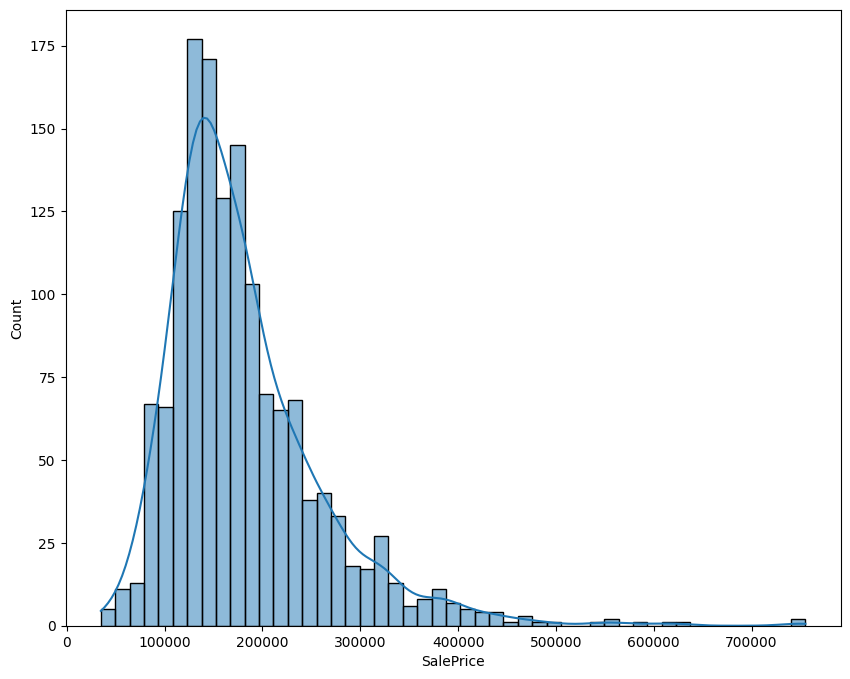

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
plt.figure(figsize=(10,8))
sns.histplot(train_df['SalePrice'], kde=True)
plt.show()

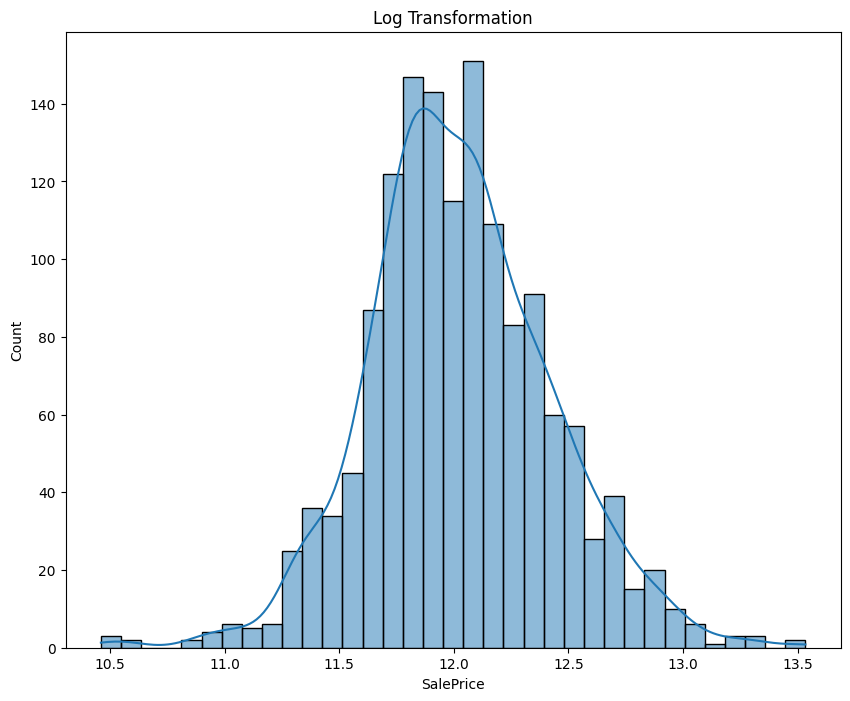

In [ ]:
# highly right skewed data..use log transformation
import numpy as np

train_df['SalePrice'] = np.log1p(train_df['SalePrice'])
plt.figure(figsize=(10,8))
sns.histplot(train_df['SalePrice'], kde=True)
plt.title('Log Transformation')
plt.show()

In [ ]:
# discover strongest predictive features.
corr_matrix = train_df.corr(numeric_only = True)
# print(corr_matrix)
sale_corr = corr_matrix['SalePrice'].sort_values(ascending=False)
print(sale_corr)



SalePrice        1.000000
OverallQual      0.817185
GrLivArea        0.700927
GarageCars       0.680625
GarageArea       0.650888
TotalBsmtSF      0.612134
1stFlrSF         0.596981
FullBath         0.594771
YearBuilt        0.586570
YearRemodAdd     0.565608
TotRmsAbvGrd     0.534422
GarageYrBlt      0.495794
Fireplaces       0.489450
MasVnrArea       0.430809
BsmtFinSF1       0.372023
LotFrontage      0.353288
WoodDeckSF       0.334135
OpenPorchSF      0.321053
2ndFlrSF         0.319300
HalfBath         0.313982
LotArea          0.257320
BsmtFullBath     0.236224
BsmtUnfSF        0.221985
BedroomAbvGr     0.209043
ScreenPorch      0.121208
PoolArea         0.069798
MoSold           0.057330
3SsnPorch        0.054900
BsmtFinSF2       0.004832
BsmtHalfBath    -0.005149
Id              -0.017942
MiscVal         -0.020021
OverallCond     -0.036868
YrSold          -0.037263
LowQualFinSF    -0.037963
MSSubClass      -0.073959
KitchenAbvGr    -0.147548
EnclosedPorch   -0.149050
Name: SalePr

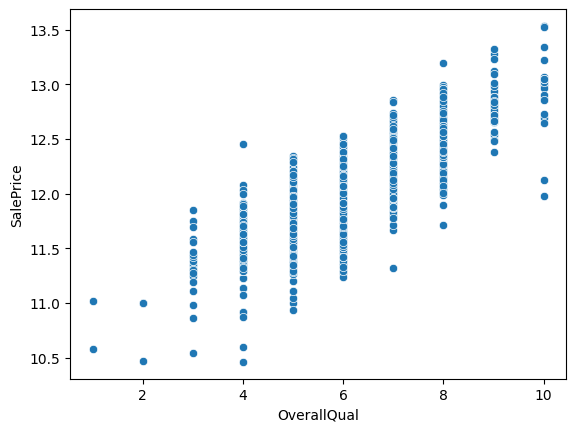

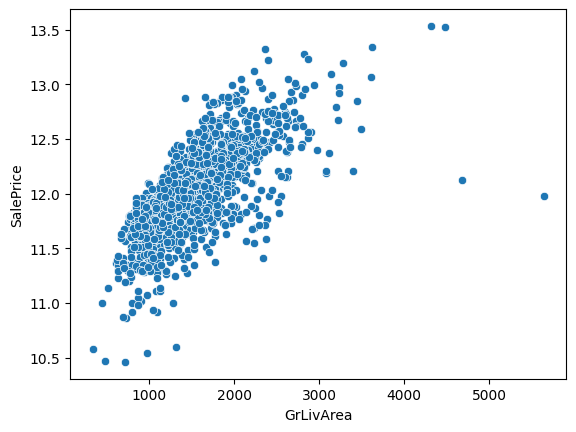

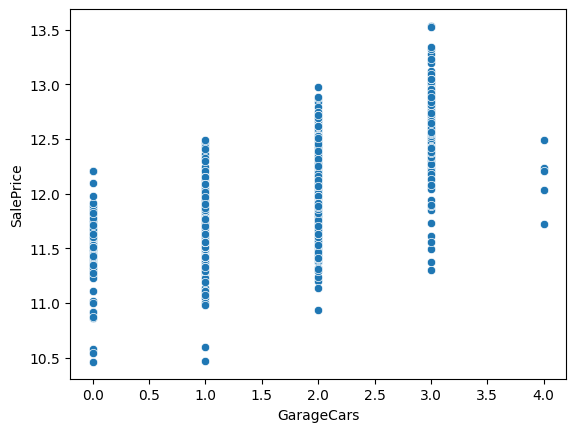

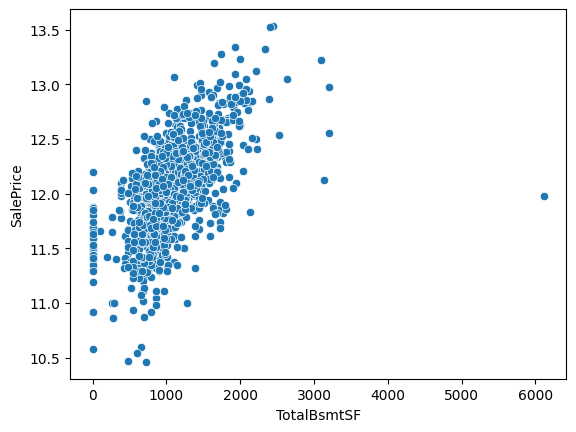

In [ ]:
top_features = [
    "OverallQual",
    "GrLivArea",
    "GarageCars",
    "TotalBsmtSF"
]

for col in top_features:

    sns.scatterplot(
        x=train_df[col],
        y=train_df["SalePrice"]
    )

    plt.show()

In [ ]:
train_df = train_df.drop(
    train_df[
        (train_df["GrLivArea"] > 4000) &
        (train_df["SalePrice"] < 13)
    ].index
)

In [ ]:
# EDA
train_df["TotalSF"] = (
    train_df["TotalBsmtSF"] +
    train_df["1stFlrSF"] +
    train_df["2ndFlrSF"]
)

test_df["TotalSF"] = (
    test_df["TotalBsmtSF"] +
    test_df["1stFlrSF"] +
    test_df["2ndFlrSF"]
)

In [ ]:
train_df["HouseAge"] = (
    train_df["YrSold"] - train_df["YearBuilt"]
)

test_df["HouseAge"] = (
    test_df["YrSold"] - test_df["YearBuilt"]
)

In [ ]:
train_df["Remodeled"] = (
    train_df["YearBuilt"] != train_df["YearRemodAdd"]
).astype(int)

test_df["Remodeled"] = (
    test_df["YearBuilt"] != test_df["YearRemodAdd"]
).astype(int)

In [ ]:
train_df["TotalBath"] = (
    train_df["FullBath"] +
    0.5 * train_df["HalfBath"] +
    train_df["BsmtFullBath"] +
    0.5 * train_df["BsmtHalfBath"]
)

test_df["TotalBath"] = (
    test_df["FullBath"] +
    0.5 * test_df["HalfBath"] +
    test_df["BsmtFullBath"] +
    0.5 * test_df["BsmtHalfBath"]
)

In [ ]:
# again feature engineering for better results
train_df["TotalPorchSF"] = (
    train_df["OpenPorchSF"] +
    train_df["EnclosedPorch"] +
    train_df["3SsnPorch"] +
    train_df["ScreenPorch"]
)

test_df["TotalPorchSF"] = (
    test_df["OpenPorchSF"] +
    test_df["EnclosedPorch"] +
    test_df["3SsnPorch"] +
    test_df["ScreenPorch"]
)

In [ ]:
train_df["Qual_TotalSF"] = (
    train_df["OverallQual"] *
    train_df["TotalSF"]
)

test_df["Qual_TotalSF"] = (
    test_df["OverallQual"] *
    test_df["TotalSF"]
)

In [ ]:
train_df["LuxuryScore"] = (
    train_df["OverallQual"] *
    train_df["GrLivArea"]
)

test_df["LuxuryScore"] = (
    test_df["OverallQual"] *
    test_df["GrLivArea"]
)

In [ ]:
train_df["QualLivArea"] = (
    train_df["OverallQual"] *
    train_df["GrLivArea"]
)

test_df["QualLivArea"] = (
    test_df["OverallQual"] *
    test_df["GrLivArea"]
)

In [ ]:
train_df["BathQual"] = (
    train_df["TotalBath"] *
    train_df["OverallQual"]
)

test_df["BathQual"] = (
    test_df["TotalBath"] *
    test_df["OverallQual"]
)

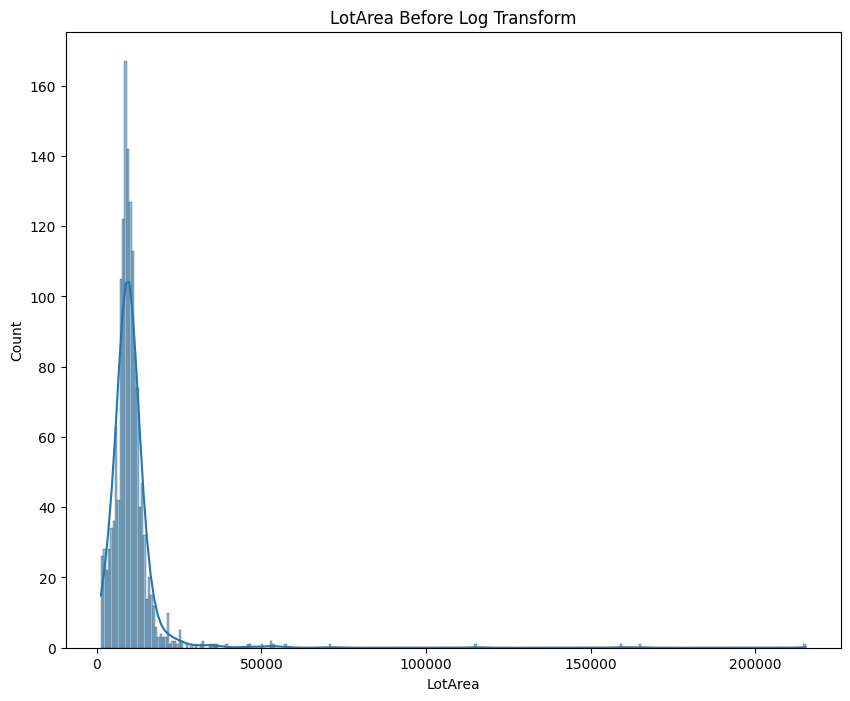

In [ ]:
# lets see how skewed is LotArea
plt.figure(figsize=(10,8))
sns.histplot(train_df['LotArea'], kde=True)
plt.title("LotArea Before Log Transform")
plt.show()

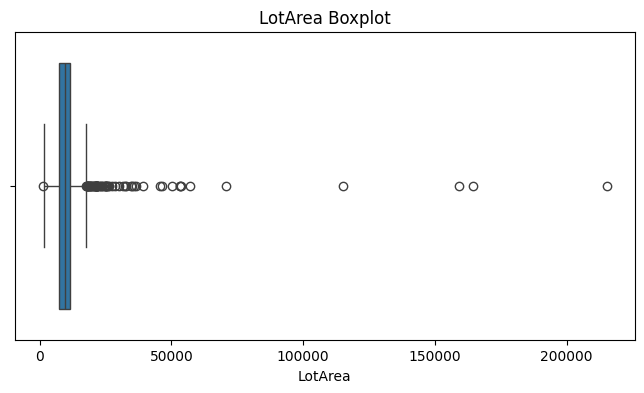

In [ ]:
plt.figure(figsize=(8,4))

sns.boxplot(x=train_df["LotArea"])

plt.title("LotArea Boxplot")

plt.show()

In [ ]:
# /Measure skewness

from scipy.stats import skew
numeric_feats = train_df.select_dtypes(['int64', 'float64']).columns

skewed_feats = train_df[numeric_feats].apply(
    lambda x: skew(x.dropna())
)

skewed_feats = skewed_feats[
    abs(skewed_feats)> 0.75
]

print(skewed_feats.sort_values(ascending = False))

MiscVal          24.434913
PoolArea         15.932532
LotArea          12.560986
3SsnPorch        10.286510
LowQualFinSF      8.995688
KitchenAbvGr      4.480268
BsmtFinSF2        4.247550
ScreenPorch       4.114690
BsmtHalfBath      4.095895
EnclosedPorch     3.083987
MasVnrArea        2.685003
OpenPorchSF       2.337421
TotalPorchSF      2.009401
LotFrontage       1.546174
WoodDeckSF        1.544214
LuxuryScore       1.492289
QualLivArea       1.492289
MSSubClass        1.405563
Qual_TotalSF      1.391617
GrLivArea         1.009951
BsmtUnfSF         0.919955
1stFlrSF          0.886723
2ndFlrSF          0.812121
TotalSF           0.803494
BsmtFinSF1        0.764002
dtype: float64


In [ ]:
for col in skewed_feats.index:
  train_df[col] = np.log1p(train_df[col])
  test_df[col] = np.log1p(test_df[col])

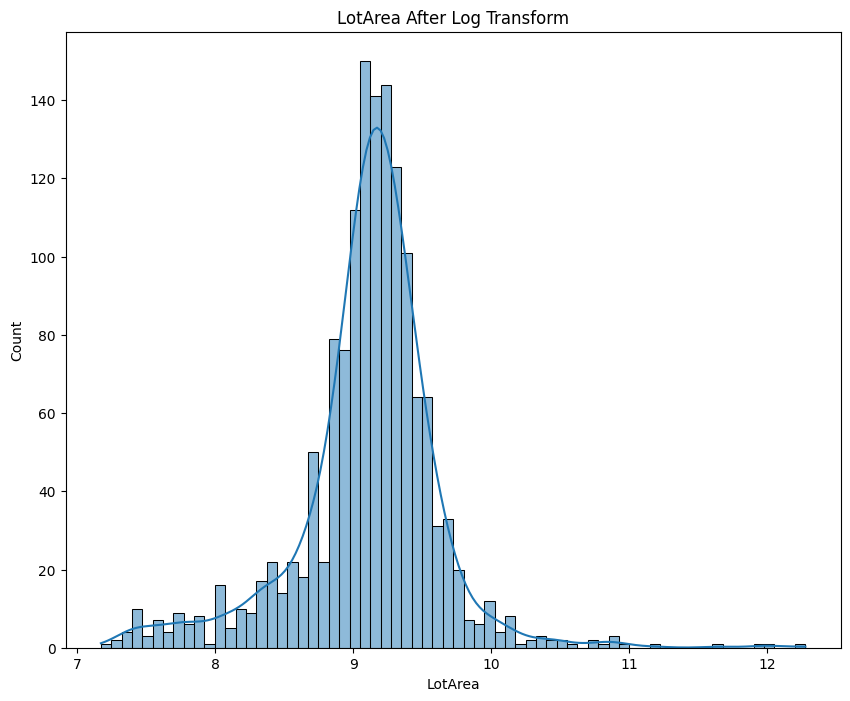

In [ ]:
plt.figure(figsize=(10,8))
sns.histplot(train_df['LotArea'], kde=True)
plt.title("LotArea After Log Transform")
plt.show()

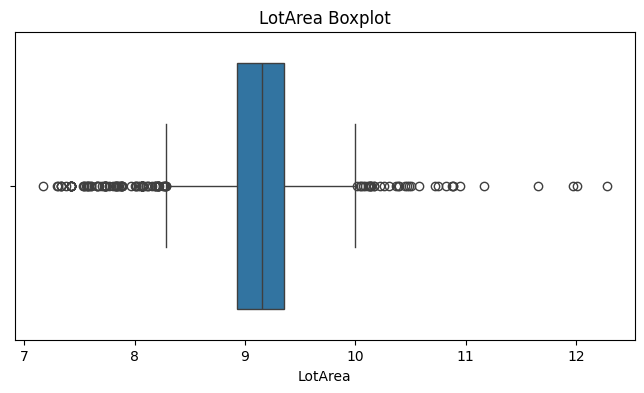

In [ ]:
plt.figure(figsize=(8,4))

sns.boxplot(x=train_df["LotArea"])

plt.title("LotArea Boxplot")

plt.show()

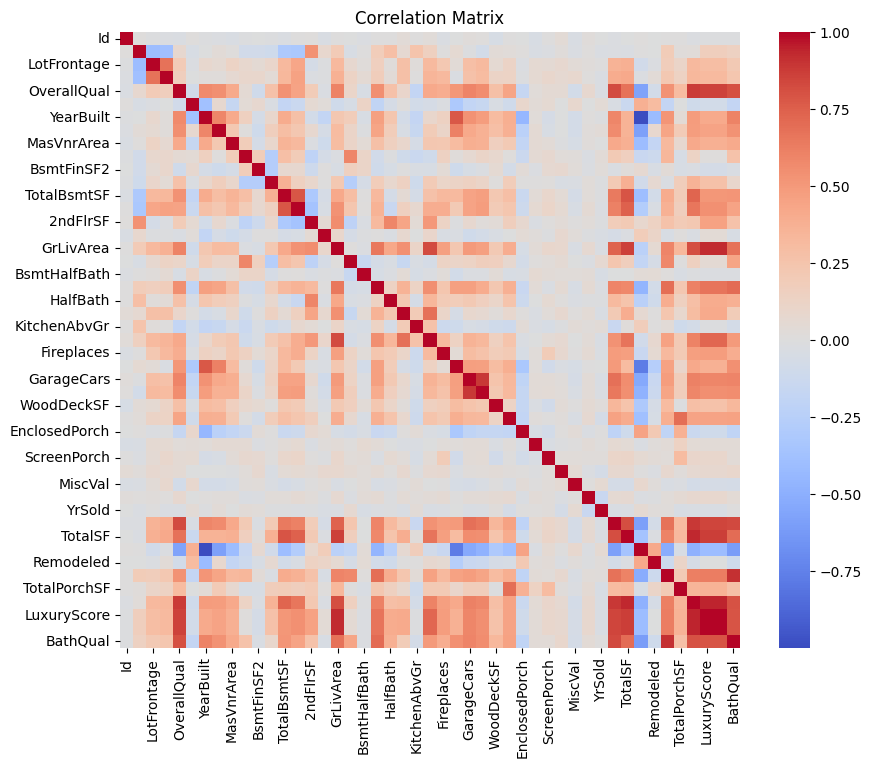

In [ ]:
corr_matrix = train_df.corr(numeric_only = True)
plt.figure(figsize = (10,8))

sns.heatmap(
    corr_matrix,
    cmap = 'coolwarm',
)

plt.title("Correlation Matrix")
plt.show()

In [ ]:
# Getting top correlations only
sale_corr = corr_matrix['SalePrice'].sort_values(ascending=False)
sale_corr.head(20)

,SalePrice
SalePrice,1.000000
Qual_TotalSF,0.883824
QualLivArea,0.850217
LuxuryScore,0.850217
BathQual,0.829977
OverallQual,0.821405
TotalSF,0.817818
GrLivArea,0.737431
GarageCars,0.681033
TotalBath,0.676678


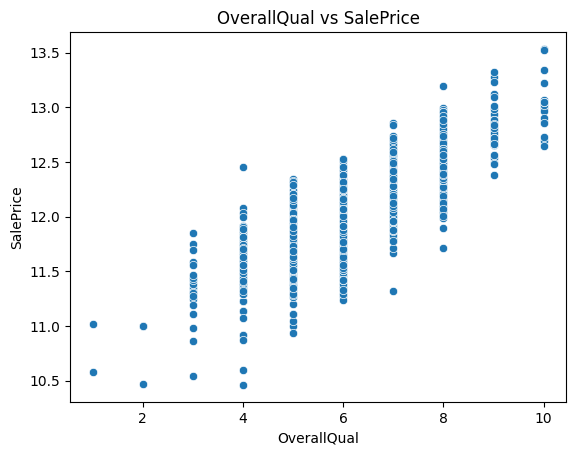

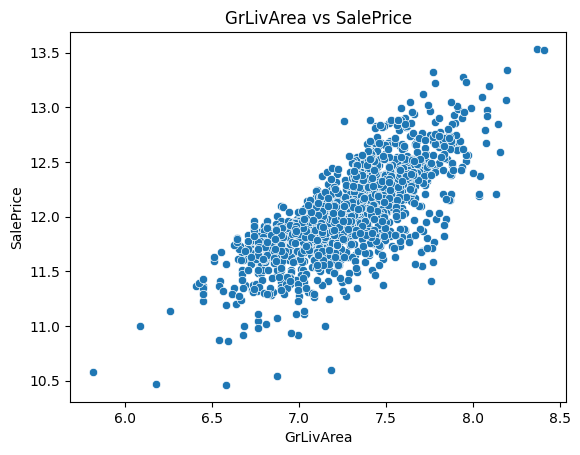

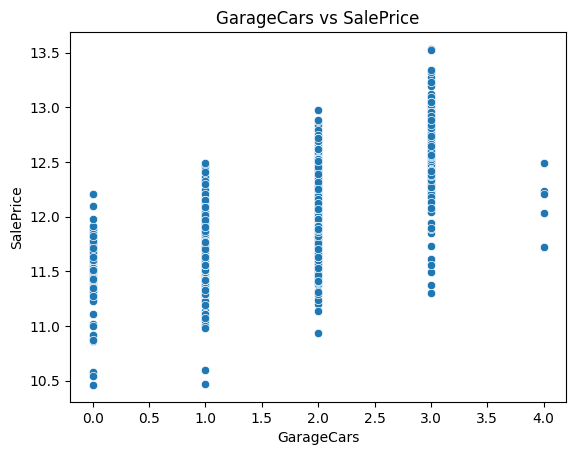

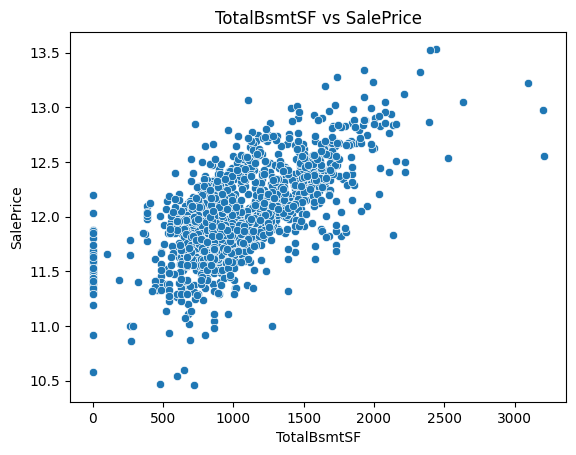

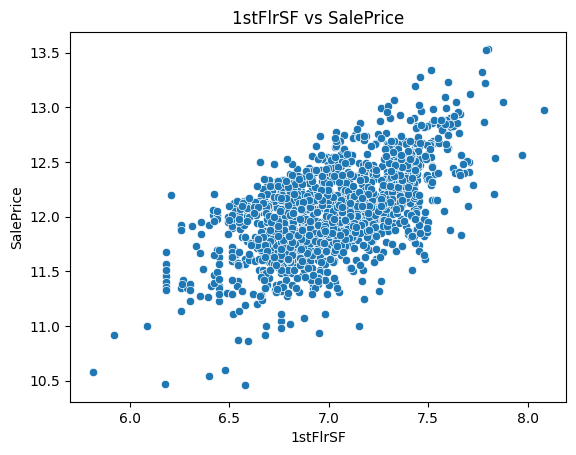

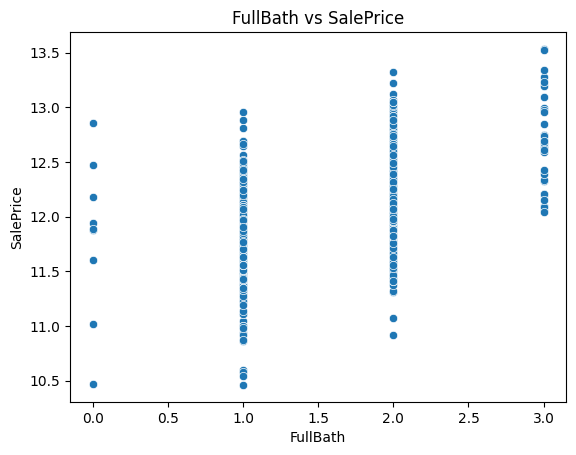

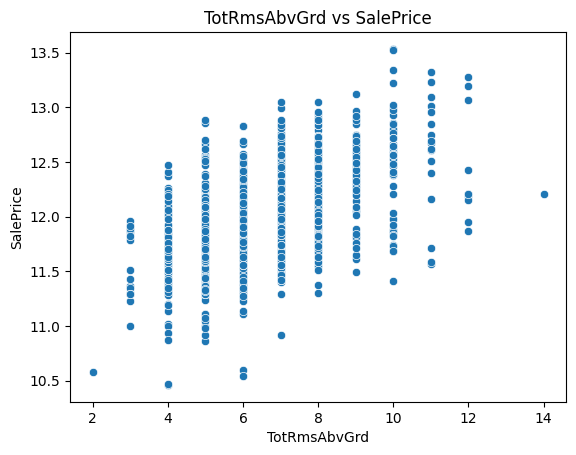

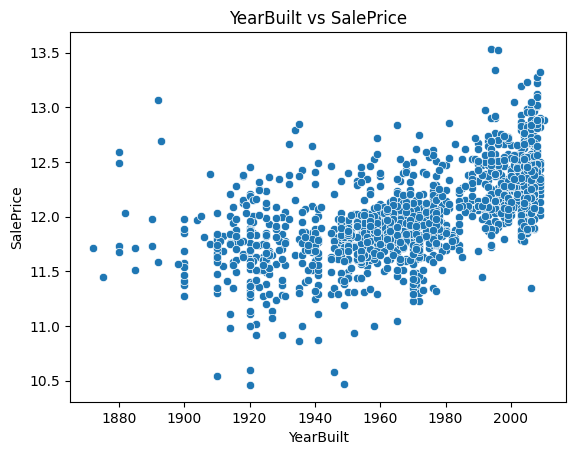

In [ ]:
# Pairwise Relationship
top_features=  [
    'OverallQual',
    'GrLivArea',
    'GarageCars',
    'TotalBsmtSF',
    '1stFlrSF',
    'FullBath',
    'TotRmsAbvGrd',
    'YearBuilt'
]

for col in top_features:
    sns.scatterplot(
        x=train_df[col],
        y=train_df['SalePrice']
    )

    plt.title(f"{col} vs SalePrice")
    plt.show()

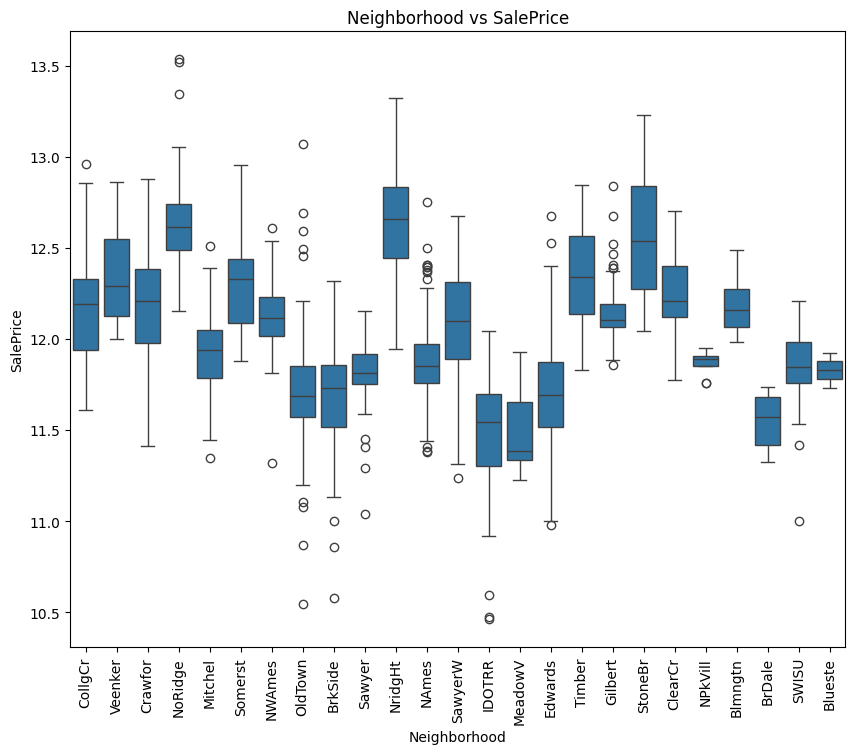

In [ ]:
# Analysing categorical features(Underrated)
plt.figure(figsize=(10,8))

sns.boxplot(
    x= train_df["Neighborhood"],
    y = train_df["SalePrice"]
)
plt.xticks(rotation=90)
plt.title("Neighborhood vs SalePrice")
plt.show()

In [ ]:
train_df.isnull().sum().sort_values(
    ascending=False
).head(20)

,0
MasVnrArea,8
Id,0
MSZoning,0
LotFrontage,0
LotArea,0
Street,0
Alley,0
LotShape,0
LandContour,0
MSSubClass,0


In [ ]:
test_df.isnull().sum().sort_values(
    ascending=False
).head(20)

,0
MasVnrArea,15
MSZoning,4
Utilities,2
TotalBath,2
BsmtHalfBath,2
BsmtFullBath,2
BathQual,2
Functional,2
Exterior1st,1
BsmtFinSF1,1


In [ ]:
for col in train_df.select_dtypes(
    include=['int64', 'float64']
).columns:

    train_df[col] = train_df[col].fillna(
        train_df[col].median()
    )

    if col in test_df.columns:
        test_df[col] = test_df[col].fillna(
            train_df[col].median()
        )

In [ ]:
train_df.isnull().sum().sum()

np.int64(0)

In [ ]:
test_df.isnull().sum().sum()

np.int64(12)

In [ ]:
cat_cols = train_df.select_dtypes(include = ['object']).columns
cat_cols

Index(['MSZoning', 'Street', 'Alley', 'LotShape', 'LandContour', 'Utilities',
       'LotConfig', 'LandSlope', 'Neighborhood', 'Condition1', 'Condition2',
       'BldgType', 'HouseStyle', 'RoofStyle', 'RoofMatl', 'Exterior1st',
       'Exterior2nd', 'MasVnrType', 'ExterQual', 'ExterCond', 'Foundation',
       'BsmtQual', 'BsmtCond', 'BsmtExposure', 'BsmtFinType1', 'BsmtFinType2',
       'Heating', 'HeatingQC', 'CentralAir', 'Electrical', 'KitchenQual',
       'Functional', 'FireplaceQu', 'GarageType', 'GarageFinish', 'GarageQual',
       'GarageCond', 'PavedDrive', 'PoolQC', 'Fence', 'MiscFeature',
       'SaleType', 'SaleCondition'],
      dtype='object')

In [ ]:
# One hot encoding
train_df = pd.get_dummies(train_df)
test_df = pd.get_dummies(test_df)

In [ ]:
train_df

,Id,MSSubClass,LotFrontage,LotArea,OverallQual,OverallCond,YearBuilt,YearRemodAdd,MasVnrArea,BsmtFinSF1,BsmtFinSF2,BsmtUnfSF,TotalBsmtSF,1stFlrSF,2ndFlrSF,LowQualFinSF,GrLivArea,BsmtFullBath,BsmtHalfBath,FullBath,HalfBath,BedroomAbvGr,KitchenAbvGr,TotRmsAbvGrd,Fireplaces,GarageYrBlt,GarageCars,GarageArea,WoodDeckSF,OpenPorchSF,EnclosedPorch,3SsnPorch,ScreenPorch,PoolArea,MiscVal,MoSold,YrSold,SalePrice,TotalSF,HouseAge,Remodeled,TotalBath,TotalPorchSF,Qual_TotalSF,LuxuryScore,QualLivArea,BathQual,MSZoning_C (all),MSZoning_FV,MSZoning_RH,MSZoning_RL,MSZoning_RM,Street_Grvl,Street_Pave,Alley_Grvl,Alley_None,Alley_Pave,LotShape_IR1,LotShape_IR2,LotShape_IR3,LotShape_Reg,LandContour_Bnk,LandContour_HLS,LandContour_Low,LandContour_Lvl,Utilities_AllPub,Utilities_NoSeWa,LotConfig_Corner,LotConfig_CulDSac,LotConfig_FR2,LotConfig_FR3,LotConfig_Inside,LandSlope_Gtl,LandSlope_Mod,LandSlope_Sev,Neighborhood_Blmngtn,Neighborhood_Blueste,Neighborhood_BrDale,Neighborhood_BrkSide,Neighborhood_ClearCr,Neighborhood_CollgCr,Neighborhood_Crawfor,Neighborhood_Edwards,Neighborhood_Gilbert,Neighborhood_IDOTRR,Neighborhood_MeadowV,Neighborhood_Mitchel,Neighborhood_NAmes,Neighborhood_NPkVill,Neighborhood_NWAmes,Neighborhood_NoRidge,Neighborhood_NridgHt,Neighborhood_OldTown,Neighborhood_SWISU,Neighborhood_Sawyer,Neighborhood_SawyerW,Neighborhood_Somerst,Neighborhood_StoneBr,Neighborhood_Timber,Neighborhood_Veenker,Condition1_Artery,Condition1_Feedr,Condition1_Norm,Condition1_PosA,Condition1_PosN,Condition1_RRAe,Condition1_RRAn,Condition1_RRNe,Condition1_RRNn,Condition2_Artery,Condition2_Feedr,Condition2_Norm,Condition2_PosA,Condition2_PosN,Condition2_RRAe,Condition2_RRAn,Condition2_RRNn,BldgType_1Fam,BldgType_2fmCon,BldgType_Duplex,BldgType_Twnhs,BldgType_TwnhsE,HouseStyle_1.5Fin,HouseStyle_1.5Unf,HouseStyle_1Story,HouseStyle_2.5Fin,HouseStyle_2.5Unf,HouseStyle_2Story,HouseStyle_SFoyer,HouseStyle_SLvl,RoofStyle_Flat,RoofStyle_Gable,RoofStyle_Gambrel,RoofStyle_Hip,RoofStyle_Mansard,RoofStyle_Shed,RoofMatl_CompShg,RoofMatl_Membran,RoofMatl_Metal,RoofMatl_Roll,RoofMatl_Tar&Grv,RoofMatl_WdShake,RoofMatl_WdShngl,Exterior1st_AsbShng,Exterior1st_AsphShn,Exterior1st_BrkComm,Exterior1st_BrkFace,Exterior1st_CBlock,Exterior1st_CemntBd,Exterior1st_HdBoard,Exterior1st_ImStucc,Exterior1st_MetalSd,Exterior1st_Plywood,Exterior1st_Stone,Exterior1st_Stucco,Exterior1st_VinylSd,Exterior1st_Wd Sdng,Exterior1st_WdShing,Exterior2nd_AsbShng,Exterior2nd_AsphShn,Exterior2nd_Brk Cmn,Exterior2nd_BrkFace,Exterior2nd_CBlock,Exterior2nd_CmentBd,Exterior2nd_HdBoard,Exterior2nd_ImStucc,Exterior2nd_MetalSd,Exterior2nd_Other,Exterior2nd_Plywood,Exterior2nd_Stone,Exterior2nd_Stucco,Exterior2nd_VinylSd,Exterior2nd_Wd Sdng,Exterior2nd_Wd Shng,MasVnrType_BrkCmn,MasVnrType_BrkFace,MasVnrType_None,MasVnrType_Stone,ExterQual_Ex,ExterQual_Fa,ExterQual_Gd,ExterQual_TA,ExterCond_Ex,ExterCond_Fa,ExterCond_Gd,ExterCond_Po,ExterCond_TA,Foundation_BrkTil,Foundation_CBlock,Foundation_PConc,Foundation_Slab,Foundation_Stone,Foundation_Wood,BsmtQual_Ex,BsmtQual_Fa,BsmtQual_Gd,BsmtQual_None,BsmtQual_TA,BsmtCond_Fa,BsmtCond_Gd,BsmtCond_None,BsmtCond_Po,BsmtCond_TA,BsmtExposure_Av,BsmtExposure_Gd,BsmtExposure_Mn,BsmtExposure_No,BsmtExposure_None,BsmtFinType1_ALQ,BsmtFinType1_BLQ,BsmtFinType1_GLQ,BsmtFinType1_LwQ,BsmtFinType1_None,BsmtFinType1_Rec,BsmtFinType1_Unf,BsmtFinType2_ALQ,BsmtFinType2_BLQ,BsmtFinType2_GLQ,BsmtFinType2_LwQ,BsmtFinType2_None,BsmtFinType2_Rec,BsmtFinType2_Unf,Heating_Floor,Heating_GasA,Heating_GasW,Heating_Grav,Heating_OthW,Heating_Wall,HeatingQC_Ex,HeatingQC_Fa,HeatingQC_Gd,HeatingQC_Po,HeatingQC_TA,CentralAir_N,CentralAir_Y,Electrical_FuseA,Electrical_FuseF,Electrical_FuseP,Electrical_Mix,Electrical_SBrkr,KitchenQual_Ex,KitchenQual_Fa,KitchenQual_Gd,KitchenQual_TA,Functional_Maj1,Functional_Maj2,Functional_Min1,Functional_Min2,Functional_Mod,Functional_Sev,Functional_Typ,FireplaceQu_Ex,FireplaceQu_Fa,FireplaceQu_Gd,FireplaceQu_None,FireplaceQu_Po,FireplaceQu_TA,GarageType_2Types,Gara

In [ ]:
train_df, test_df = train_df.align(
    test_df,
    join = 'left',
    axis = 1,
    fill_value=0
)

In [ ]:
train_df.shape

(1458, 312)

In [ ]:
y = train_df["SalePrice"]
X = train_df.drop("SalePrice", axis=1)

X_test = test_df.copy()

In [ ]:
from sklearn.model_selection import train_test_split
X_train, X_val, y_train, y_val = train_test_split(
    X,
    y,
    test_size = 0.2,
    random_state = 42
)

# from sklearn.preprocessing import StandardScaler

# scaler = StandardScaler()

# X_train_scaled = scaler.fit_transform(X_train)

# X_val_scaled = scaler.transform(X_val)

# # Ensure X_test does not have the 'SalePrice' column if it was added during alignment
# if 'SalePrice' in X_test.columns:
#     X_test = X_test.drop('SalePrice', axis=1)

# X_test_scaled = scaler.transform(X_test)

In [ ]:
print(X_train.shape)
print(X_val.shape)
print(y_train.shape)
print(y_val.shape)

(1166, 311)
(292, 311)
(1166,)
(292,)


In [ ]:
# Ridge Regression model
from sklearn.linear_model import Ridge
from sklearn.model_selection import GridSearchCV
ridge_params = {
    "alpha": [0.01, 10, 5, 50, 0.001, 1, 0.003]
}
ridge_grid = GridSearchCV(
    Ridge(),
    ridge_params,
    scoring = 'neg_root_mean_squared_error',
    cv = 5
)
ridge_grid.fit(X_train, y_train)
# ridge_model = Ridge()
# ridge_model.fit(X_train, y_train)

GridSearchCV(cv=5, estimator=Ridge(),
             param_grid={'alpha': [0.01, 10, 5, 50, 0.001, 1, 0.003]},
             scoring='neg_root_mean_squared_error')

In [ ]:
print("Best Alpha:")

print(ridge_grid.best_params_)

print("\nBest RMSE:")

print(-ridge_grid.best_score_)

Best Alpha:
{'alpha': 10}

Best RMSE:
0.11481982210082586


In [ ]:
val_preds = ridge_grid.predict(X_val)

In [ ]:
# val_preds[:10]

In [ ]:
# y_val[:10]

In [ ]:
# print(np.expm1(val_preds[:10]))

# print(np.expm1(y_val[:10]))

In [ ]:
# best for now
# proper way is by creating  dataframes not needed rn
for actual, pred in zip(
    np.expm1(y_val[:10]),
    np.expm1(val_preds[:10])
):

    print(f"Actual: {actual:.0f} | Predicted: {pred:.0f}")

Actual: 190000 | Predicted: 235010
Actual: 100000 | Predicted: 99789
Actual: 115000 | Predicted: 102484
Actual: 159000 | Predicted: 168694
Actual: 315500 | Predicted: 326588
Actual: 137500 | Predicted: 151661
Actual: 311500 | Predicted: 244235
Actual: 310000 | Predicted: 331096
Actual: 281000 | Predicted: 288293
Actual: 135500 | Predicted: 149817


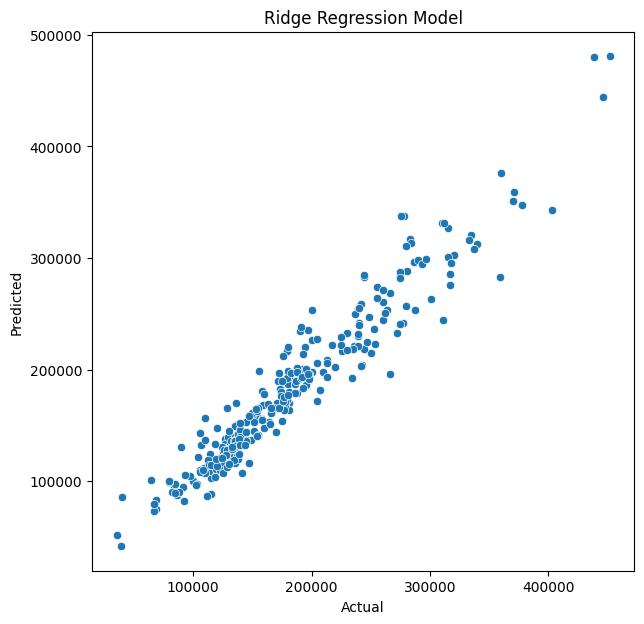

In [ ]:
# lets visualize it
plt.figure(figsize=(7,7))
sns.scatterplot(
    x = np.expm1(y_val),
    y = np.expm1(val_preds)
)
plt.xlabel("Actual")
plt.ylabel("Predicted")
plt.title("Ridge Regression Model")
plt.show()


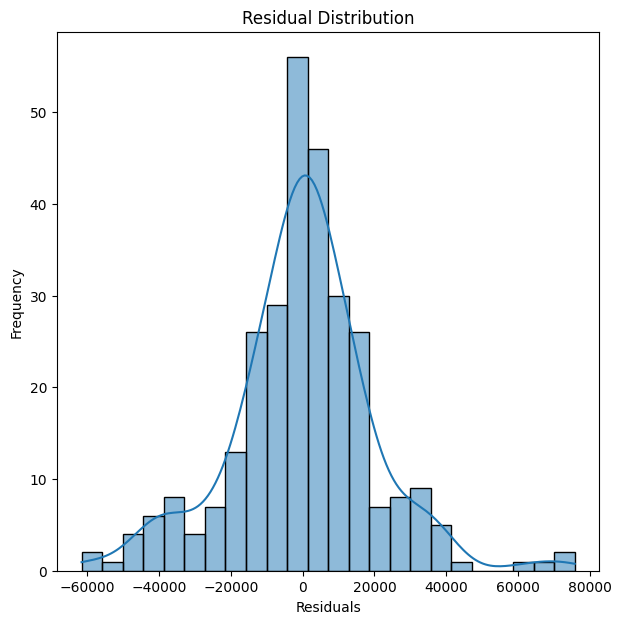

In [ ]:
residuals = (
    np.expm1(y_val) - np.expm1(val_preds)
)

plt.figure(figsize=(7,7))

sns.histplot(
    residuals,
    kde=True
)
plt.title("Residual Distribution")
plt.xlabel("Residuals")
plt.ylabel("Frequency")

plt.show()

In [ ]:
from sklearn.metrics import root_mean_squared_error
rmse = root_mean_squared_error(
    y_val,
    val_preds
)

rmse

0.11723990288530563

Next steps:
| Improvement              | Why                          |
| ------------------------ | ---------------------------- |
| Cross-validation         | more reliable evaluation     |
| Lasso/ElasticNet         | compare regularization       |
| Feature importance       | understand signals           |
| More feature engineering | improve representation       |
| Tree models              | capture nonlinearity         |
| Gradient boosting        | stronger tabular performance |


In [ ]:
from sklearn.model_selection import cross_val_score
cv_scores = -cross_val_score(
    Ridge(),
    X,
    y,
    scoring = 'neg_root_mean_squared_error',
    cv = 5
)
print("Cross Validation RMSE scores: ")
print(cv_scores)
print("/nAverage RMSE:")
cv_scores.mean()

Cross Validation RMSE scores: 
[0.11244567 0.12223677 0.12887688 0.10690883 0.11674801]
/nAverage RMSE:


np.float64(0.11744323195292179)

In [ ]:
from sklearn.linear_model import Lasso

lasso = Lasso(alpha=0.0005)

lasso.fit(X_train, y_train)

lasso_preds = lasso.predict(X_val)

/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_coordinate_descent.py:695: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 6.159e+00, tolerance: 1.836e-02
  model = cd_fast.enet_coordinate_descent(


In [ ]:
for actual, pred in zip(
    np.expm1(y_val[:10]),
    np.expm1(lasso_preds[:10])
):

  print(f"Actual: {actual:.0f} | Predicted: {pred:.0f}")

Actual: 190000 | Predicted: 232543
Actual: 100000 | Predicted: 100124
Actual: 115000 | Predicted: 102604
Actual: 159000 | Predicted: 166310
Actual: 315500 | Predicted: 324092
Actual: 137500 | Predicted: 147863
Actual: 311500 | Predicted: 250453
Actual: 310000 | Predicted: 331332
Actual: 281000 | Predicted: 283304
Actual: 135500 | Predicted: 149076


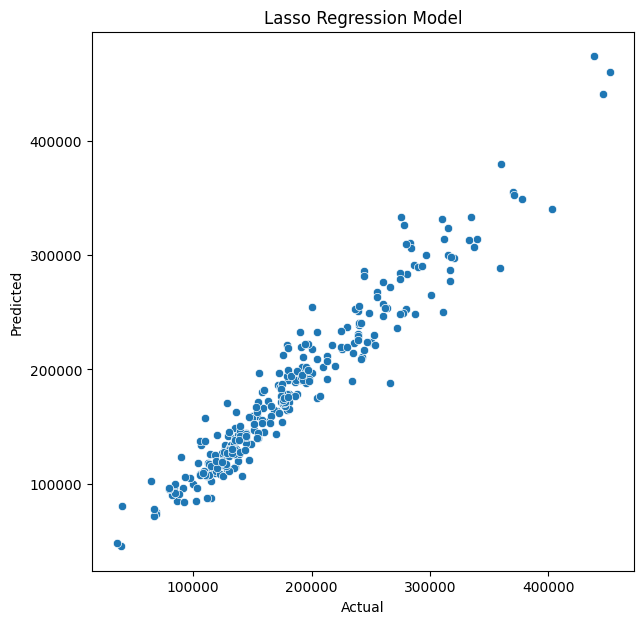

In [ ]:
plt.figure(figsize = (7,7))
sns.scatterplot(
    x = np.expm1(y_val),
    y = np.expm1(lasso_preds)
)
plt.xlabel("Actual")
plt.ylabel("Predicted")
plt.title("Lasso Regression Model")
plt.show()

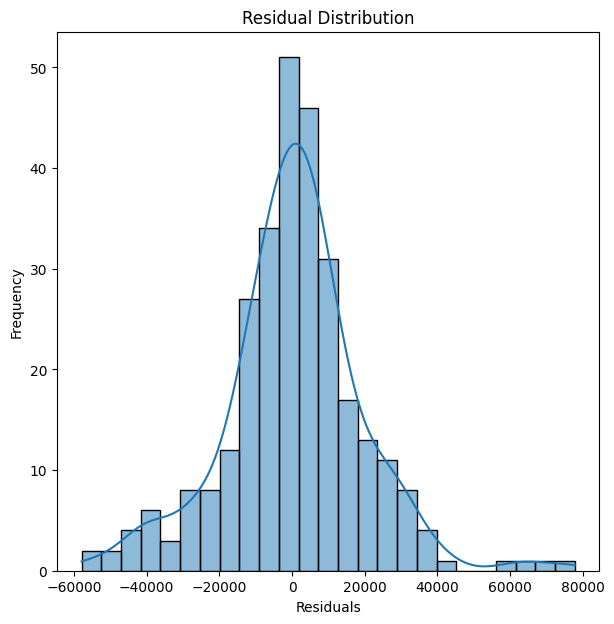

In [ ]:
residuals = (
    np.expm1(y_val) - np.expm1(lasso_preds)
)

plt.figure(figsize=(7,7))

sns.histplot(
    residuals,
    kde=True
)
plt.title("Residual Distribution")
plt.xlabel("Residuals")
plt.ylabel("Frequency")

plt.show()

In [ ]:
lasso_rmse = root_mean_squared_error(
    y_val,
    lasso_preds)
print(lasso_rmse)

0.11233824260714331


In [ ]:
coefficients = pd.Series(
    lasso.coef_,
    index = X_train.columns
)
coefficients.sort_values(ascending = False).head(20)

,0
GrLivArea,0.314726
Neighborhood_Crawfor,0.102370
Neighborhood_StoneBr,0.102103
Exterior1st_BrkFace,0.083607
LotArea,0.076244
Functional_Typ,0.069635
SaleType_New,0.061770
Neighborhood_BrkSide,0.052838
BsmtQual_Ex,0.049868
KitchenQual_Ex,0.045675


In [ ]:
# Using random Forest
from sklearn.ensemble import RandomForestRegressor
rf_model = RandomForestRegressor(
    n_estimators = 250,
    max_depth = 10,
    min_samples_split = 8,
    min_samples_leaf = 3,
    max_features = 0.8,
    random_state = 42
)
rf_model.fit(X_train, y_train)

RandomForestRegressor(max_depth=10, max_features=0.8, min_samples_leaf=3,
                      min_samples_split=8, n_estimators=250, random_state=42)

In [ ]:
rf_preds = rf_model.predict(X_val)

In [ ]:
rf_rmse = root_mean_squared_error(
    y_val,
    rf_preds
)
print(rf_rmse)

0.1415141746538872


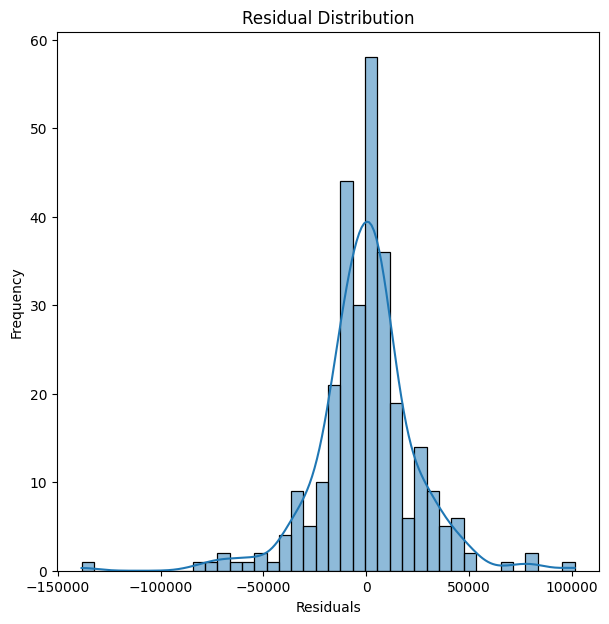

In [ ]:
residuals = (
    np.expm1(y_val) - np.expm1(rf_preds)
)

plt.figure(figsize=(7,7))

sns.histplot(
    residuals,
    kde=True
)
plt.title("Residual Distribution")
plt.xlabel("Residuals")
plt.ylabel("Frequency")

plt.show()

In [ ]:
for actual, pred in zip(
    np.expm1(y_val[:10]),
    np.expm1(rf_preds[:10])
):

  print(f"Actual: {actual:.0f} | Predicted: {pred:.0f}")

Actual: 190000 | Predicted: 211701
Actual: 100000 | Predicted: 104719
Actual: 115000 | Predicted: 116038
Actual: 159000 | Predicted: 155830
Actual: 315500 | Predicted: 309195
Actual: 137500 | Predicted: 149114
Actual: 311500 | Predicted: 209950
Actual: 310000 | Predicted: 318329
Actual: 281000 | Predicted: 263919
Actual: 135500 | Predicted: 132301


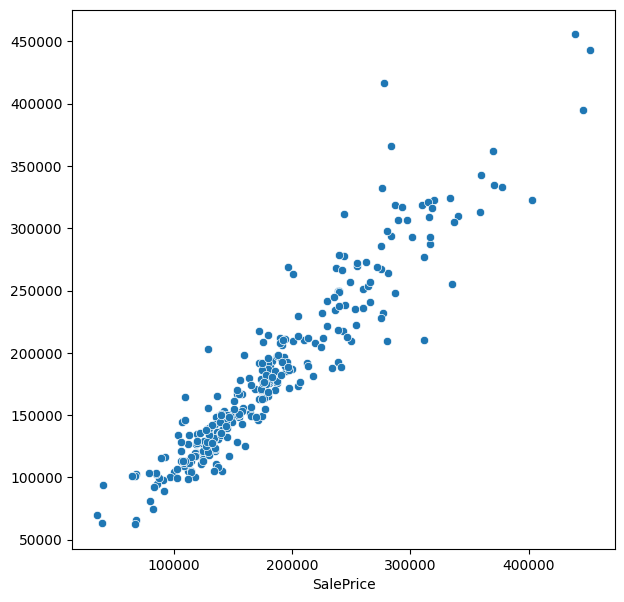

In [ ]:
plt.figure(figsize=(7,7))

sns.scatterplot(
    x=np.expm1(y_val),
    y=np.expm1(rf_preds)
)

plt.show()

In [ ]:
importance = pd.Series(
    rf_model.feature_importances_,
    index=X_train.columns
)

print(
    importance.sort_values(
        ascending=False
    ).head(15)
)

Qual_TotalSF    0.638661
BathQual        0.079809
QualLivArea     0.062722
LuxuryScore     0.049958
TotalSF         0.021304
GarageArea      0.010263
YearRemodAdd    0.008275
GarageCars      0.007499
LotArea         0.007148
BsmtFinSF1      0.006713
HouseAge        0.006326
YearBuilt       0.006083
BsmtUnfSF       0.005829
CentralAir_Y    0.004827
MSZoning_RM     0.004568
dtype: float64


In [ ]:
# Gradient boosting now
from sklearn.ensemble import GradientBoostingRegressor
gbr = GradientBoostingRegressor(
    n_estimators=250,
    learning_rate=0.05,
    max_depth=5,
    min_samples_split=10,
    min_samples_leaf=3,
    max_features=0.8,
    random_state = 42
)
gbr.fit(X_train, y_train)
gbr_preds = gbr.predict(X_val)

In [ ]:
gbr_rmse = root_mean_squared_error(
    y_val,
    gbr_preds
)
print(grb_rmse)

0.12823606190933637


In [ ]:
for actual, pred in zip(
    np.expm1(y_val[:10]),
    np.expm1(gbr_preds[:10])
):

  print(f"Actual: {actual:.0f} | Predicted: {pred:.0f}")


Actual: 190000 | Predicted: 216171
Actual: 100000 | Predicted: 96188
Actual: 115000 | Predicted: 111724
Actual: 159000 | Predicted: 156903
Actual: 315500 | Predicted: 314159
Actual: 137500 | Predicted: 143575
Actual: 311500 | Predicted: 241504
Actual: 310000 | Predicted: 327943
Actual: 281000 | Predicted: 274328
Actual: 135500 | Predicted: 137017


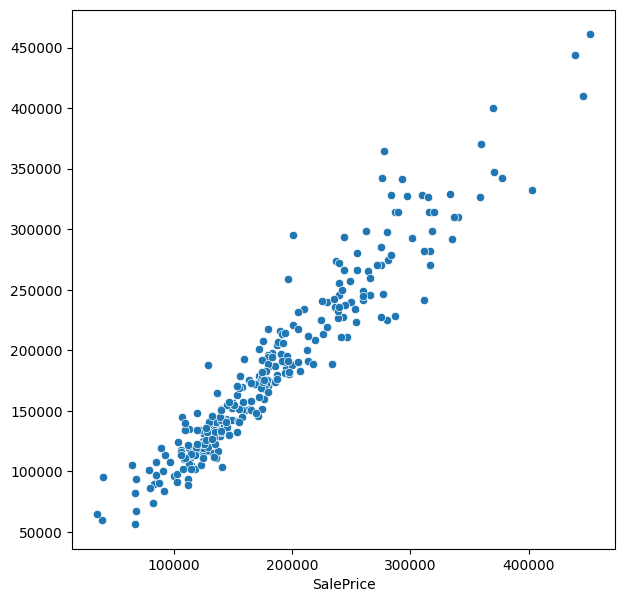

In [ ]:
plt.figure(figsize=(7,7))

sns.scatterplot(
    x=np.expm1(y_val),
    y=np.expm1(gbr_preds)
)

plt.show()

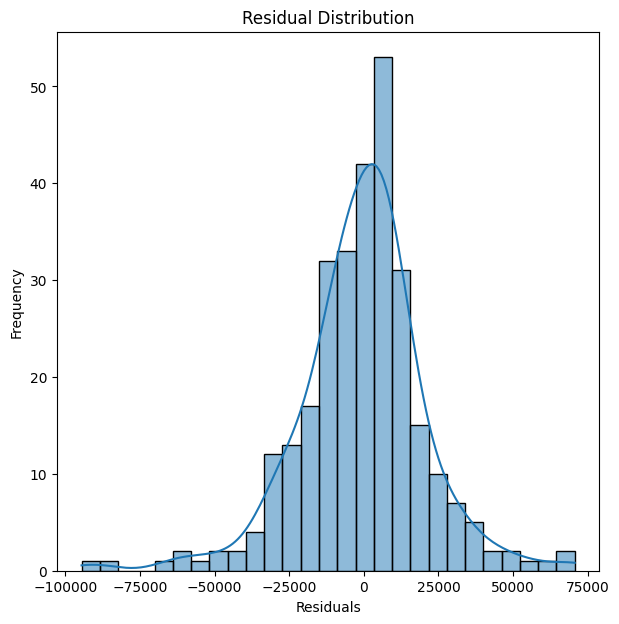

In [ ]:
residuals = (
    np.expm1(y_val) - np.expm1(gbr_preds)
)

plt.figure(figsize=(7,7))

sns.histplot(
    residuals,
    kde=True
)
plt.title("Residual Distribution")
plt.xlabel("Residuals")
plt.ylabel("Frequency")

plt.show()

In [ ]:
ensemble_preds = (
    val_preds +
    lasso_preds +
    gbr_preds
) / 3

In [ ]:
ensemble_rmse = root_mean_squared_error(
    y_val,
    ensemble_preds
)

print(ensemble_rmse)

0.11388298205475675


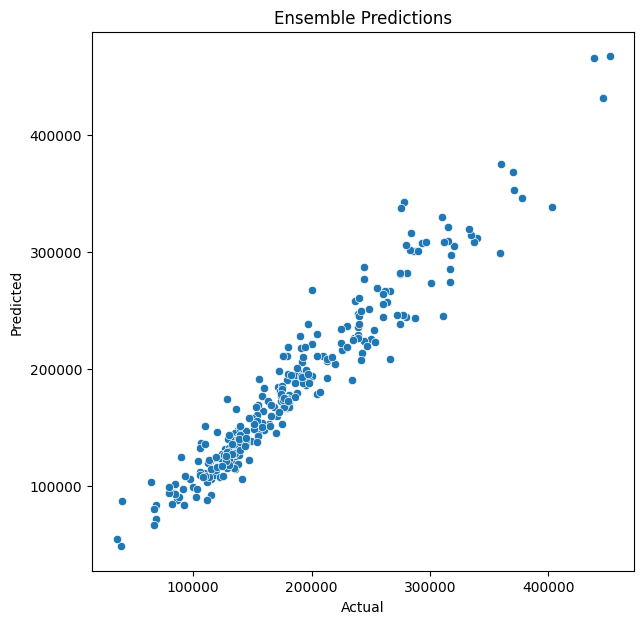

In [ ]:
plt.figure(figsize=(7,7))

sns.scatterplot(
    x=np.expm1(y_val),
    y=np.expm1(ensemble_preds)
)

plt.xlabel("Actual")
plt.ylabel("Predicted")

plt.title("Ensemble Predictions")

plt.show()

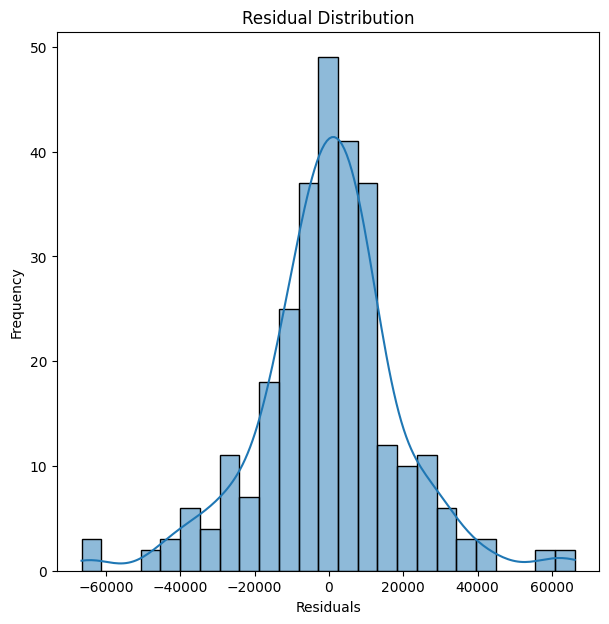

In [ ]:
residuals = (
    np.expm1(y_val) - np.expm1(ensemble_preds)
)

plt.figure(figsize=(7,7))

sns.histplot(
    residuals,
    kde=True
)
plt.title("Residual Distribution")
plt.xlabel("Residuals")
plt.ylabel("Frequency")

plt.show()

In [ ]:
for actual, pred in zip(
    np.expm1(y_val[:10]),
    np.expm1(ensemble_preds[:10])
):

    print(f"Actual: {actual:.0f} | Predicted: {pred:.0f}")

Actual: 190000 | Predicted: 227752
Actual: 100000 | Predicted: 98684
Actual: 115000 | Predicted: 105517
Actual: 159000 | Predicted: 163889
Actual: 315500 | Predicted: 321568
Actual: 137500 | Predicted: 147663
Actual: 311500 | Predicted: 245369
Actual: 310000 | Predicted: 330120
Actual: 281000 | Predicted: 281916
Actual: 135500 | Predicted: 145182


In [ ]:
# Using XGBoost
!pip install XGBoost

In [ ]:
from xgboost import XGBRegressor
xgb_model = XGBRegressor(
    n_estimators = 1000,
    learning_rate = 0.05,
    max_depth = 3,
    # min_child_weight = 1,
    # gamma = 0,
    subsample = 0.8,
    colsample_bytree = 0.8,
    random_state = 42
)
xgb_model.fit(X_train, y_train)


XGBRegressor(base_score=None, booster=None, callbacks=None,
             colsample_bylevel=None, colsample_bynode=None,
             colsample_bytree=0.8, device=None, early_stopping_rounds=None,
             enable_categorical=False, eval_metric=None, feature_types=None,
             feature_weights=None, gamma=None, grow_policy=None,
             importance_type=None, interaction_constraints=None,
             learning_rate=0.05, max_bin=None, max_cat_threshold=None,
             max_cat_to_onehot=None, max_delta_step=None, max_depth=3,
             max_leaves=None, min_child_weight=None, missing=nan,
             monotone_constraints=None, multi_strategy=None, n_estimators=1000,
             n_jobs=None, num_parallel_tree=None, ...)

In [ ]:
xgb_preds = xgb_model.predict(X_val)

In [ ]:
xgb_rmse = root_mean_squared_error(
    y_val,
    xgb_preds
)

print("XGBoost RMSE:", xgb_rmse)

XGBoost RMSE: 0.12543553356964926


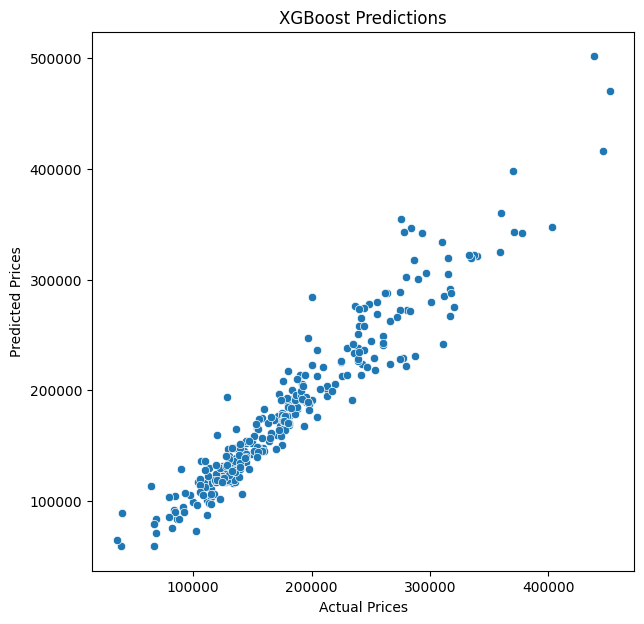

In [ ]:
plt.figure(figsize=(7,7))

sns.scatterplot(
    x=np.expm1(y_val),
    y=np.expm1(xgb_preds)
)

plt.xlabel("Actual Prices")
plt.ylabel("Predicted Prices")

plt.title("XGBoost Predictions")

plt.show()

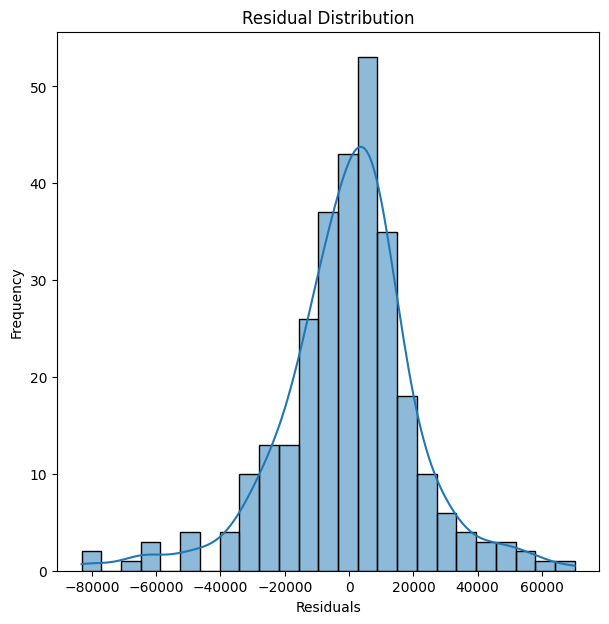

In [ ]:
residuals = (
    np.expm1(y_val) - np.expm1(xgb_preds)
)

plt.figure(figsize=(7,7))

sns.histplot(
    residuals,
    kde=True
)
plt.title("Residual Distribution")
plt.xlabel("Residuals")
plt.ylabel("Frequency")

plt.show()

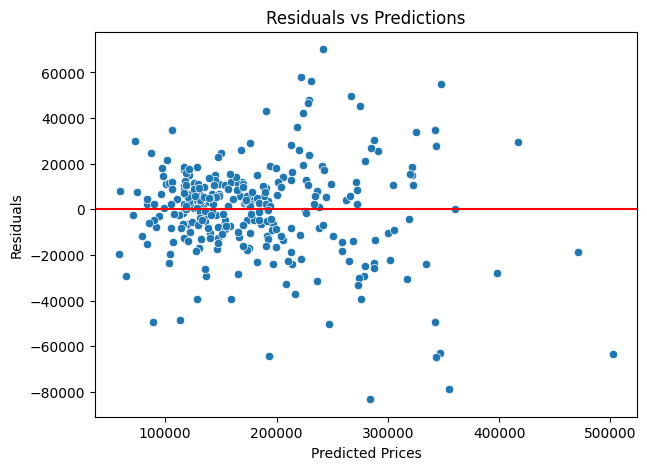

In [ ]:
plt.figure(figsize=(7,5))

sns.scatterplot(
    x=np.expm1(xgb_preds),
    y=residuals
)

plt.axhline(0, color='red')

plt.xlabel("Predicted Prices")
plt.ylabel("Residuals")

plt.title("Residuals vs Predictions")

plt.show()

In [ ]:
importance = pd.Series(
    xgb_model.feature_importances_,
    index=X_train.columns
)

importance = importance.sort_values(
    ascending=False
)

print(importance.head(15))

Qual_TotalSF        0.196593
BathQual            0.097215
CentralAir_N        0.044082
MSZoning_RM         0.039371
FireplaceQu_None    0.038275
LuxuryScore         0.035095
GarageCars          0.028672
MSZoning_RL         0.025201
CentralAir_Y        0.023833
BsmtQual_Ex         0.023308
Fireplaces          0.022243
TotalSF             0.022041
PavedDrive_N        0.019467
YearRemodAdd        0.014355
GarageFinish_Unf    0.012070
dtype: float32


In [ ]:
model_results = pd.DataFrame({
    "Model": [
        "Ridge Regression",
        "Lasso Regression",
        "Random Forest",
        "Gradient Boosting",
        "XGBoost",
        "Final Ensemble"
    ],

    "RMSE": [
        rmse,
        lasso_rmse,
        rf_rmse,
        gbr_rmse,
        xgb_rmse,
        ensemble_rmse
    ],

    "Observations": [
        "Stable linear baseline with good generalization",

        "Best single model with strong regularization and feature selection",

        "Captured nonlinear patterns but showed higher variance and overfitting tendencies",

        "Learned nonlinear interactions but exhibited higher variance and wider residual spread",
        "Captured nonlinear relationships but generalized less effectively than regularized linear models on this dataset",

        "Improved prediction stability through model averaging but slightly underperformed the best individual model"
    ]
})

model_results.sort_values(
    by="RMSE"
)

,Model,RMSE,Observations
1,Lasso Regression,0.112338,Best single model with strong regularization a...
5,Final Ensemble,0.113883,Improved prediction stability through model av...
0,Ridge Regression,0.117240,Stable linear baseline with good generalization
4,XGBoost,0.125436,Captured nonlinear relationships but generaliz...
3,Gradient Boosting,0.128236,Learned nonlinear interactions but exhibited h...
2,Random Forest,0.141514,Captured nonlinear patterns but showed higher ...


# Final Model Analysis

## Objective
The goal of this project was to predict house sale prices using advanced regression techniques and structured machine learning workflows.

---

## Data Preprocessing
Several preprocessing techniques were applied to improve model performance:

- Missing value handling
- Log transformation of skewed features
- Outlier removal
- Feature engineering
- One-hot encoding for categorical variables

The target variable `SalePrice` was log-transformed to reduce skewness and stabilize variance.

---

## Feature Engineering
Additional features were created to improve representation of housing characteristics:

- Total square footage
- Total bathrooms
- Interaction features such as quality × living area

These engineered features significantly improved linear model performance.

---

## Model Comparison
Multiple regression models were trained and evaluated using RMSE:

- Ridge Regression
- Lasso Regression
- Random Forest Regressor
- Gradient Boosting Regressor
- XGBoost Regressor
- Ensemble Model

---

## Key Observations

### 1. Linear Models Performed Surprisingly Well
After preprocessing and feature engineering, the dataset became highly linear in nature. Regularized linear models generalized better than more flexible nonlinear models.

### 2. Tree-Based Models Showed Higher Variance
Random Forest and XGBoost captured nonlinear patterns but produced wider residual distributions and signs of overfitting due to the relatively small dataset size.

### 3. Ensemble Learning Improved Stability
Averaging predictions from multiple models reduced prediction variance and improved overall RMSE.

### 4. Luxury Houses Were Harder To Predict
Residual analysis revealed that expensive houses were consistently underpredicted, indicating regression toward the mean and sparse representation of luxury properties in the dataset.

---

## Final Conclusion
The Lasso Regression model achieved the lowest RMSE and showed the strongest generalization performance across the validation set.

The ensemble model improved prediction stability and reduced variance, although it slightly underperformed the best individual model.

This project demonstrated the importance of:
- thoughtful preprocessing
- proper validation
- regularization
- residual analysis
- feature engineering
- ensemble learning

in building robust machine learning systems.
# Final Takeaway

This project demonstrated that strong preprocessing, feature engineering, and regularization can outperform more complex nonlinear models on structured tabular datasets.

# Rather than relying solely on model complexity, careful handling of skewness, missing values, feature interactions, and validation strategy proved to be more impactful for generalization performance.